# HD209458b (example 12) — EXHALE output

Plots the converged (or current) EXHALE run in `output/` for the Wind-AE
warm-start HD209458b example (`Domain mode: Spherical`, `IC mode: windae`).
Run the model first (`./run_EXHALE.sh` from this folder, or `../../EXHALE.x`),
then execute these cells. Reads `output/Hydro_ioniz.txt` and
`output/Ion_species.txt` via the shared `examples/exhale_io.py` loader.

In [7]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '..')          # examples/ holds exhale_io.py
import exhale_io as io

In [8]:
hyd = io.load_hydro('output/Hydro_ioniz.txt')
r_ion, ion = io.load_ions('output/Ion_species.txt')
inp = io.read_input('input.inp')

r = hyd['r']
print('planet :', inp.get('Planet name', '?'))
print('rows   :', r.size)
print('radius :', round(r.min(), 4), '..', round(r.max(), 4), 'Rp')
print('T base :', round(float(hyd['T'][0]), 1), 'K')

planet : ?
rows   : 504
radius : 0.9998 .. 10.0 Rp
T base : 1450.0 K


## Hydrodynamic profiles ($T$, $v$, $n$, $p$)

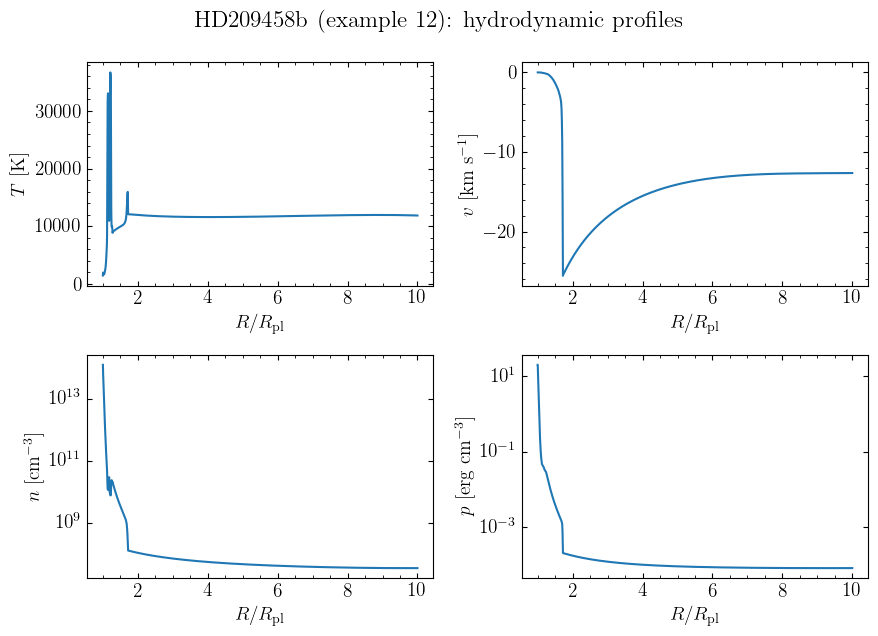

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(9, 6.5))
ax[0, 0].plot(r, hyd['T'])
ax[0, 0].set_ylabel(r'$T$ [K]')
ax[0, 1].plot(r, hyd['v'] / 1.0e5)
ax[0, 1].set_ylabel(r'$v$ [km s$^{-1}$]')
ax[1, 0].semilogy(r, hyd['n'])
ax[1, 0].set_ylabel(r'$n$ [cm$^{-3}$]')
ax[1, 1].semilogy(r, hyd['p'])
ax[1, 1].set_ylabel(r'$p$ [erg cm$^{-3}$]')
for a in ax.flat:
    a.set_xlabel(r'$R/R_{\rm pl}$')
fig.suptitle('HD209458b (example 12): hydrodynamic profiles')
fig.tight_layout()

## Ionization structure

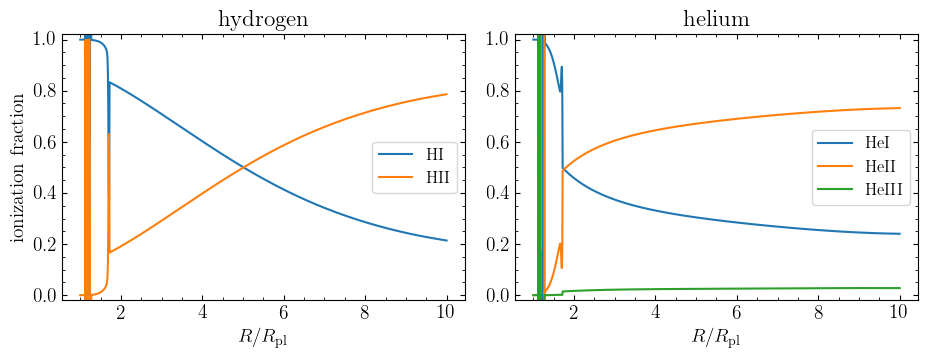

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))

nH = ion['HI'] + ion['HII']
ax[0].plot(r_ion, ion['HI'] / nH, label='HI')
ax[0].plot(r_ion, ion['HII'] / nH, label='HII')
ax[0].set_title('hydrogen')
ax[0].set_ylabel('ionization fraction')
ax[0].legend()

nHe = ion['HeI'] + ion['HeII'] + ion['HeIII']
for s in ['HeI', 'HeII', 'HeIII']:
    ax[1].plot(r_ion, ion[s] / nHe, label=s)
ax[1].set_title('helium')
ax[1].legend()

for a in ax:
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.set_ylim(-0.02, 1.02)
fig.tight_layout()

## Heating and cooling rates

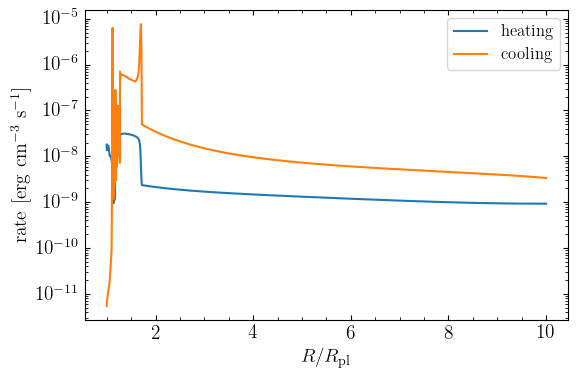

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(r, np.abs(hyd['heat']), label='heating')
ax.semilogy(r, np.abs(hyd['cool']), label='cooling')
ax.set_xlabel(r'$R/R_{\rm pl}$')
ax.set_ylabel(r'rate [erg cm$^{-3}$ s$^{-1}$]')
ax.legend()
fig.tight_layout()

## Wind-AE warm-start IC vs the relaxed solution
Compares the loaded initial condition (`*_IC.txt`) with the current run.

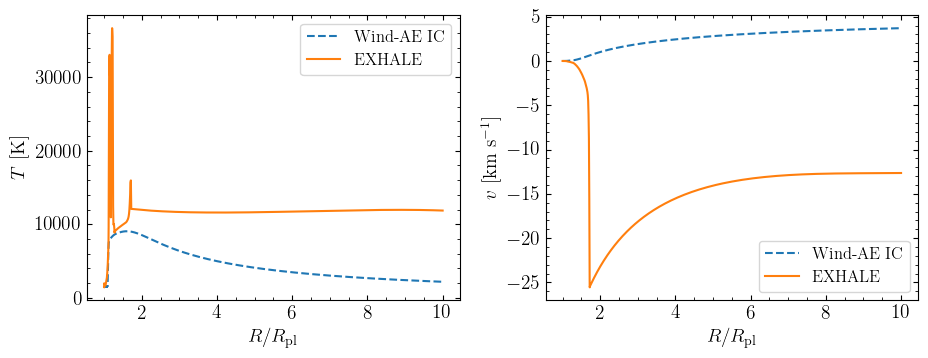

In [12]:
import os

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
if os.path.exists('output/Hydro_ioniz_IC.txt'):
    ic = io.load_hydro('output/Hydro_ioniz_IC.txt')
    ax[0].plot(ic['r'], ic['T'], '--', label='Wind-AE IC')
    ax[1].plot(ic['r'], ic['v'] / 1.0e5, '--', label='Wind-AE IC')
ax[0].plot(r, hyd['T'], label='EXHALE')
ax[1].plot(r, hyd['v'] / 1.0e5, label='EXHALE')
ax[0].set_ylabel(r'$T$ [K]')
ax[1].set_ylabel(r'$v$ [km s$^{-1}$]')
for a in ax:
    a.set_xlabel(r'$R/R_{\rm pl}$')
    a.legend()
fig.tight_layout()